In [2]:
pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 55.7 MB/s eta 0:00:00


In [3]:
pip install pointpats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 24.0 MB/s eta 0:00:00


In [4]:
pip install libpysal

In [5]:
#Importação dos pacotes:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pyproj
from PIL import Image
import plotly.express as px
import contextily as ctx
import libpysal as ps
from scipy.spatial.distance import pdist
from sklearn.cluster import DBSCAN
from pointpats import (
    distance_statistics,
    QStatistic,
    random,
    PointPattern,
)

1) Podemos dizer que existe um padrão espacial na ocorrência de crimes na cidade de Houston? Apresente a análise mais completa possível.

• Plote o sahpefile.

• Crie um mapa de pontos com as visualizações dos histogramas
das coordenadas. Inclua o contexto geográfico.

• Cria um mapa com o padrão de pontos com marca. Use como
marca o tipo de crime.

• Crie um mapa de pontos não marcado interativo.

• Estime a intensidade do Kernel usando o método scott para a
definição do raio.

• Faça uma análise da distância ao vizinho mais próximo.

• Faça uma análise da quadratura.

• Faça uma análise da Função G de Ripley.

• Use o DBSCAN para identificar clusters.

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

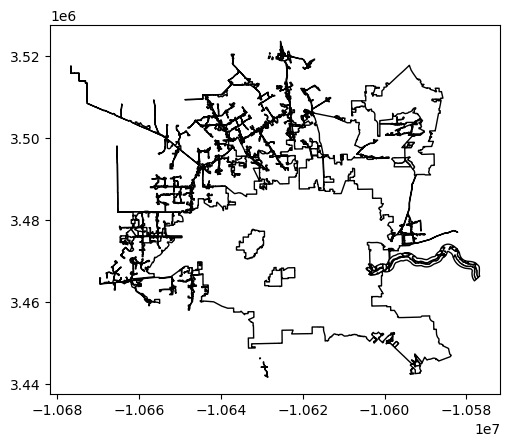

In [6]:
#1- Plotando o Shapefile:
HSTshp = gpd.read_file(filename = "Houston.zip")
HSTshp.plot(color = 'white',
           edgecolor = 'black')
HSTshp.crs #Formato WGS84 com medidas em Metro.

                time       date  hour premise  offense      beat        block  \
0     01/01/10 06:00   01/01/10     0     18A   murder  1,50E+31    9600-9699   
1     05/01/10 21:00   01/05/10    15     20A   murder      6B60    1300-1399   
2     06/01/10 04:00   01/05/10    22     18A   murder     19G50  10200-10299   
3     07/01/10 00:00   01/06/10    18     20R   murder      6B40    1000-1099   
4     07/01/10 00:00   01/06/10    18     20R   murder      8C50    8200-8299   
...              ...        ...   ...     ...      ...       ...          ...   
2243  21/07/10 18:00  7/21/2010    13     13R  robbery      1A30    1900-1999   
2244  12/07/10 16:00   07/12/10    11      70  robbery      8C40    8300-8399   
2245  19/01/10 07:00  1/19/2010     1     20A  robbery      2A60    2100-2199   
2246  27/02/10 08:00  2/27/2010     2     20D  robbery     11H40    1200-1299   
2247  07/07/10 14:00   07/07/10     9     13R  robbery      7C20    3200-3299   

         street  type suffi

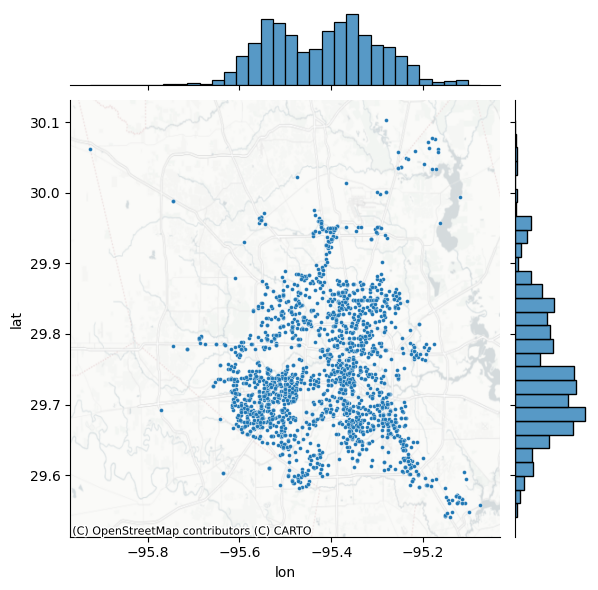

In [7]:
#2- Mapa de pontos com visualizações dos histogramas das coordenadas:
    #Importando o arquivo NYPD.csv
dados_crime = pd.read_csv(filepath_or_buffer = "Base Houston.csv")

#Definindo a mudança do Sistema de Referência de Coordenadas desejada
transformacao = pyproj.Transformer.from_crs(crs_from = "EPSG:4326",
                                            crs_to = "EPSG:3857",
                                            always_xy = True)

#Aplicando a transformação nas coordenadas originais
longT, latT = transformacao.transform(dados_crime['lon'],dados_crime['lat'])

#Incluindo as variáveis logT e latT no objeto dados_crime
dados_crime["longT"] = longT
dados_crime["latT"] = latT

joint_axes = sns.jointplot(x = "lon",
              y = "lat",
              data = dados_crime,
              s = 8)
ctx.add_basemap(
    ax = joint_axes.ax_joint,
    crs = "EPSG:4326",
    source = ctx.providers.CartoDB.PositronNoLabels)


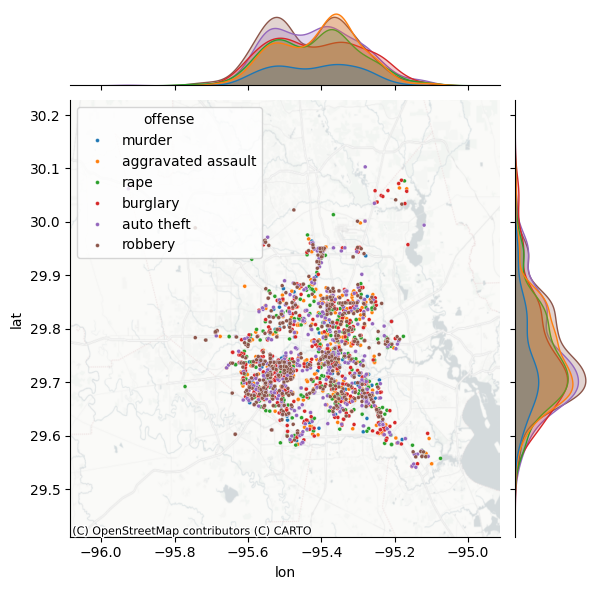

In [8]:
#3- padrão de pontos com o tipo de crime marcado:
joint_axes = sns.jointplot(x = "lon",
              y = "lat",
              data = dados_crime,
              hue = 'offense',
              s = 8)
ctx.add_basemap(
    ax = joint_axes.ax_joint,
    crs = "EPSG:4326",
    source = ctx.providers.CartoDB.PositronNoLabels)

In [9]:
#4- Criando um mapa de pontos não marcado interativo:
    #Plotando um mapa de pontos interativo
mapa_pontos = px.scatter_mapbox(data_frame = dados_crime,
                                lon = "lon",
                                lat = "lat",
                                hover_name = "offense",
                                hover_data = ["month", "day"],
                                color_discrete_sequence=["fuchsia"],
                                zoom = 9,
                                height = 500)
mapa_pontos.update_layout(mapbox_style = "open-street-map")
mapa_pontos.update_layout(margin = {"r":0,"t":0,"l":0,"b":0})
mapa_pontos.show()


Text(0.5, 1.0, 'Kernel Gaussiano e raio por Scott')

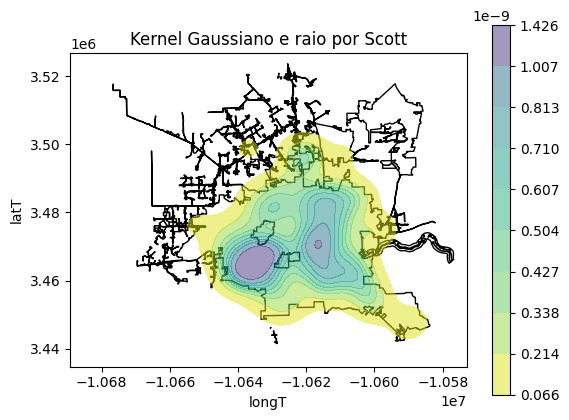

In [10]:
#5- Estimando a Intensidade de Kernel com o método Scott para definição do raio:
HSTshp.plot(color = "white",
           edgecolor = 'black')
sns.kdeplot(x = "longT",
            y = "latT",
            data = dados_crime,
            fill = True,
            alpha = 0.5,
            cbar = True,
            cmap = "viridis_r",
            bw_method = "scott").set_title("Kernel Gaussiano e raio por Scott")

  #Caso queira ver os pontos juntamente com o mapa de calor:
#sns.scatterplot(x = "longT",
#                y = "latT",
#                data = dados_crime,
#                s = 10,
#                color = "red"
#                )

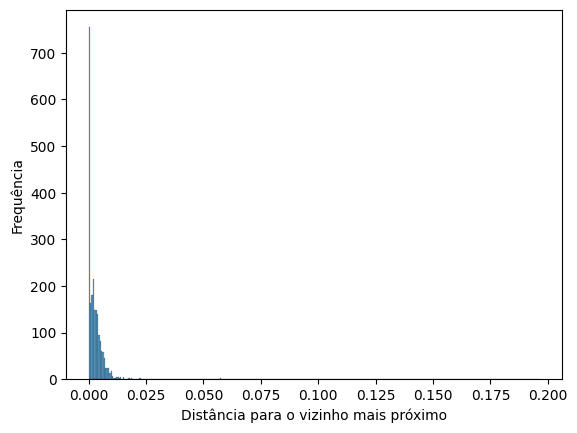

In [11]:
#6- Estimando a distância ao vizinho mais próximo:
    #Criando um objeto com as coordenadas
pontos = dados_crime[["lon","lat"]]

    #Criando o objeto coordenadas (coordendas em um array)
coordenadas = np.asarray(pontos)

    #Calculando a distância do vizinho mais próximo
nn_ixs, nn_dist = PointPattern(points = coordenadas).knn(1)

    #Criando um DataFrame com as distâncias mais próximas
d_dist = pd.DataFrame(data = nn_dist,
                   columns = ["val_dis"])

    #Histograma das distâncias mais próximas
fig_hist = sns.histplot(data = d_dist,
                        x = "val_dis")

fig_hist.set(xlabel = "Distância para o vizinho mais próximo",
             ylabel = "Frequência")

plt.show()

Conclusão: Percebe que os pontos estão agrupados (maior concentração nas distâncias menores - assimetria a esquerda)

p-valor: 0.000000000


<Axes: title={'center': 'Quadrat Count'}>

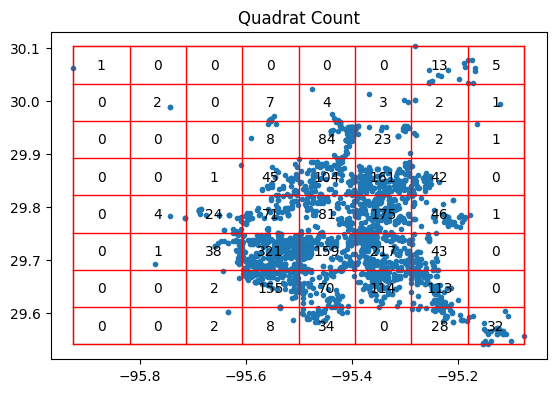

In [25]:
#7 - Realizando uma análise da quadratura:
pp = PointPattern(points = coordenadas)

#Estatística da quadratura
qstat = QStatistic(pp = pp,
                   nx = 8,
                   ny = 8)

#Plotando a análise de quadratura
#p-valor do teste de hipóteses da quadratura
print(f'p-valor: {qstat.chi2_pvalue:.9f}')

qstat.plot()

Conclusão: O p-valor indica a rejeição de H0, ou seja, há agrupamento dos pontos.

In [13]:
#8- Estimando a função G de Ripley e sua banda de confiança
gest = distance_statistics.g_test(coordinates = coordenadas,
                                  keep_simulations = True)



<ipython-input-14-4b553b87c899>:60: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.



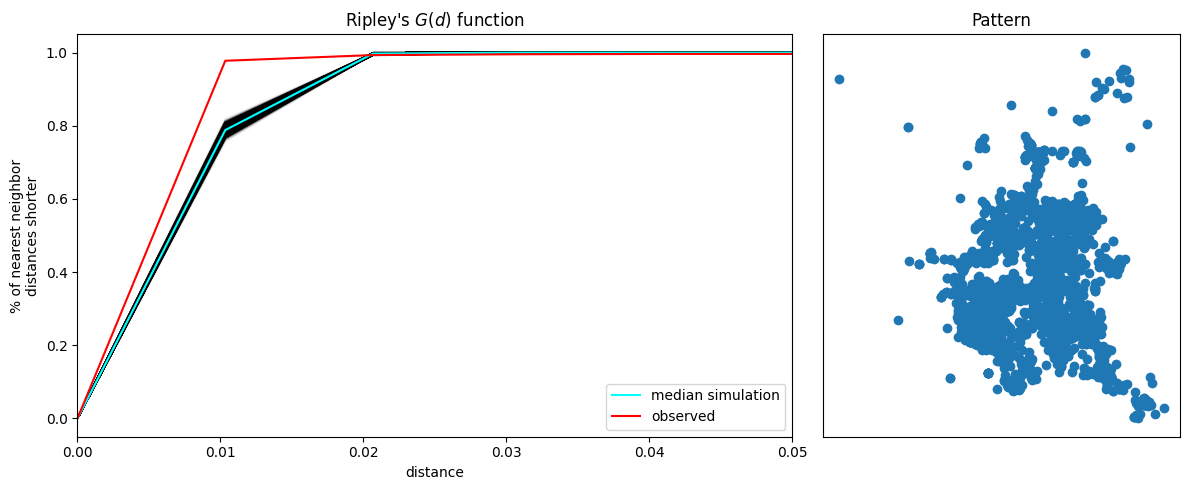

In [14]:
f, ax = plt.subplots(
    1, 2, figsize=(12, 5), gridspec_kw=dict(width_ratios=(6, 3))
)

# --- Subplot 1: Função G de Ripley ---

# Plota todas as simulações da função G geradas por processos de Poisson
# (usadas para gerar o envelope), com linhas finas e alta transparência
ax[0].plot(
    gest.support,             # eixo x: distâncias avaliadas
    gest.simulations.T,       # eixo y: simulações (cada linha é uma simulação)
    color="black",
    alpha=0.01                # transparência baixa para formar o "envelope"
)

# Plota a mediana das simulações da função G
ax[0].plot(
    gest.support,
    np.median(gest.simulations, axis=0),  # mediana ao longo das simulações
    color="cyan",
    label="median simulation"
)

# Plota a função G observada no padrão de pontos real (os dados)
ax[0].plot(
    gest.support,
    gest.statistic,          # função G observada
    label="observed",
    color="red"
)

# Define o rótulo do eixo x
ax[0].set_xlabel("distance")
ax[0].set_xlim([0, 0.05])

# Define o rótulo do eixo y (com quebra de linha)
ax[0].set_ylabel("% of nearest neighbor\ndistances shorter")

# Adiciona a legenda com os nomes definidos no argumento 'label'
ax[0].legend()

# Define o título do primeiro gráfico
ax[0].set_title(r"Ripley's $G(d)$ function")

# --- Subplot 2: padrão de pontos ---

# Plota o padrão de pontos observado no espaço (coordenadas)
ax[1].scatter(*coordenadas.T)

# Remove os ticks e rótulos dos eixos x e y para deixar o gráfico limpo
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_xticklabels([])
ax[1].set_yticklabels([])

# Define o título do segundo gráfico
ax[1].set_title("Pattern")

# Ajusta o espaçamento entre os subplots para não sobrepor elementos
f.tight_layout()

# Exibe os gráficos
plt.show()

Conclusão: Percebe-se pela função de G de Ripley que há um agrupamento dos pontos.

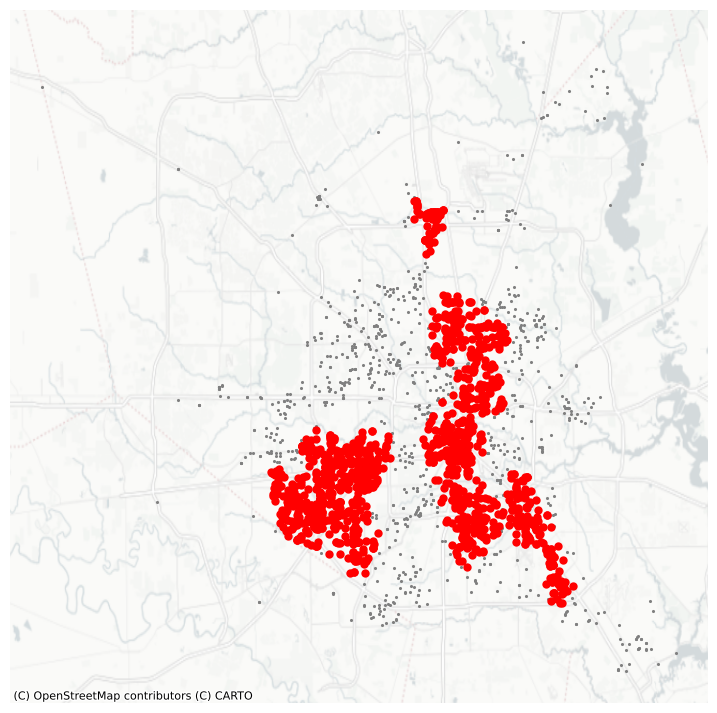

In [21]:
#Identificando os cluster com o DBSCAN
clusterer = DBSCAN(eps = 0.02,
                   min_samples = 40).fit(coordenadas)


lbls = pd.Series(data = clusterer.labels_,
                 index = dados_crime.index)

f, ax = plt.subplots(1, figsize=(9, 9))
# Subset points that are not part of any cluster (noise)
noise = dados_crime.loc[lbls == -1, ["lon", "lat"]]
# Plot ruídos em cinza
ax.scatter(noise["lon"], noise["lat"], c="grey", s=5, linewidth=0)
# Plotando cluster em vermelho
ax.scatter(
    dados_crime.loc[dados_crime.index.difference(noise.index), "lon"],
    dados_crime.loc[dados_crime.index.difference(noise.index), "lat"],
    c="red",
    linewidth=0)
# Add basemap
ctx.add_basemap(
    ax, crs = "EPSG:4326", source=ctx.providers.CartoDB.PositronNoLabels)
# Remove axes
ax.set_axis_off()
# Display the figure
plt.show()

2) Crie um mapa interativo que apresente a população de algumas
cidades americanas. Desejamos que no ponto que será criado
para indicar o local da cidade seja apresentado uma caixa com
as seguintes informações:

• Nome da cidade - variável City (título ca caixa).

• Nome do estado - variável State.

• Tamanho da população - variável Population.

Observação: os pontos devem possuir a cor verde.

In [29]:
#Importando o arquivo População USA.csv
dados_pop = pd.read_csv(filepath_or_buffer = "Populacao USA.csv")


#Plotando pontos no mapa interativo:
mapa_pontos = px.scatter_mapbox(data_frame = dados_pop,
                                lon = "lon",
                                lat = "lat",
                                hover_name = "City",
                                hover_data = ["State", "Population"],
                                color_discrete_sequence=["green"],
                                zoom = 3.6,
                                height = 500)
mapa_pontos.update_layout(mapbox_style = "open-street-map")
mapa_pontos.update_layout(margin = {"r":0,"t":0,"l":0,"b":0})
mapa_pontos.show()
